<a href="https://colab.research.google.com/github/mykhailodolitsoi/ML_RASHKA/blob/main/RASHKA_ML_3_SKLEARN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 3 — Scikit-learn

**Context**: Описание бизнес-проблемы или научного контекста.

**Tech Stack**: Python 3.12.12.

**Author**: mykhailodolitsoi

**Date**: 2026-02-01

**Source**: Machine Learning with PyTorch and Scikit-Learn, Chapter 3.


In [1]:
import numpy as np
import pandas as pd
import sklearn as sk

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

## Data Loading and Preprocessing

**Source**: sklearn.datasets.load_iris()

**Context**: Only the first 150 samples are used to form a binary classification task.

**Target**: Species (versicolor and setosa)

**Preprocessing**: sklearn.model_selection.train_test_split(), sklearn.preprocessing.StandardScaler()

In [2]:
# load_iris
iris = sk.datasets.load_iris()

X = iris.data[:, [2, 3]]
y = iris.target

# train_test_split
X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y,
                                                                       test_size=0.3,
                                                                       random_state=1,
                                                                       stratify=y)
# StandartScaler
sc = sk.preprocessing.StandardScaler()
sc.fit(X_train)
X_train_std=sc.transform(X_train)
X_test_std=sc.transform(X_test)

## Model: Perceptron. Training & Validation

**Model**: sklearn.linear_model.Perceptron(), y=wx+b

**Metrics**: sklearn.metrics.accuracy_score()

In [3]:
# perceptron
ppn = sk.linear_model.Perceptron(eta0=0.1, random_state=1)

# fit
ppn.fit(X_train_std, y_train)

# predict
y_pred = ppn.predict(X_test_std)

# accuracy_score
print("Acc: %.3f" % sk.metrics.accuracy_score(y_test, y_pred))

Acc: 0.978


## Exploratory Predicted Data Analysis

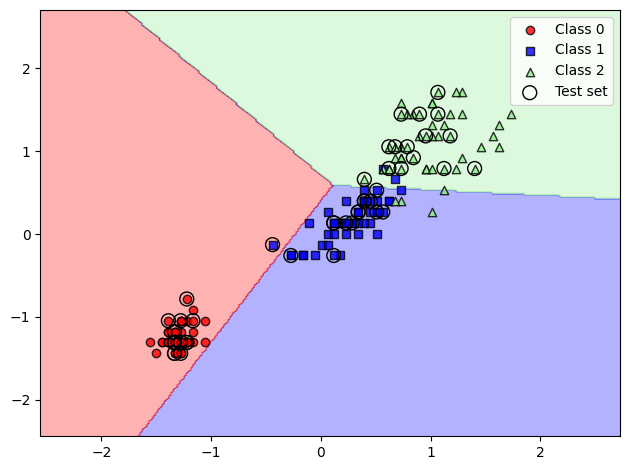

In [4]:
def plot_decision_regions(X, y, classifier,
                          test_idx=None,
                          resolution=0.02):
    markers = ('o', 's', '^', 'v', '<')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))

    lab = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    lab = lab.reshape(xx1.shape)

    plt.contourf(xx1, xx2, lab,
                 alpha=0.3,
                 cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y==cl, 0], y=X[y==cl, 1],
                    alpha=0.8,
                    c=colors[idx],
                    marker=markers[idx],
                    label=f"Class {cl}",
                    edgecolors='black')
    if test_idx:
        X_test, y_test = X[test_idx, :], y[test_idx]

        plt.scatter(X_test[:, 0], X_test[:, 1],
                    alpha=1.0,
                    c='none',
                    marker='o',
                    label="Test set",
                    edgecolors='black',
                    s=100,
                    linewidth=1)


X_combined_std = np.vstack((X_train_std, X_test_std))
y_combined = np.hstack((y_train, y_test))
plot_decision_regions(X=X_combined_std,
                      y=y_combined,
                      classifier=ppn,
                      test_idx=range(105, 150),)
plt.legend()
plt.tight_layout()
plt.show()


## Model: LogisticRegressionGD. Training & Validation

**Model**: LogisticRegressionGD | z=wx+b, y_pred=1/1+e**(-z)

**Multi-class classification method**: OvR

**Metrics**: LOG-LOSS

In [5]:
class LogisticRegressionGD:
    """
    Logistic Regression classifier using gradient descent.

    Parameters
    ----------
    eta : float, default=0.01
        Learning rate (step size) for weight updates.

    n_iter : int, default=50
        Number of passes (epochs) over the training dataset.

    random_state : int, default=1
        Seed for random number generator to initialize weights.

    Attributes
    ----------
    w_ : np.ndarray of shape (n_features,)
        Weights after fitting.

    b_ : float
        Bias (intercept) after fitting.

    Notes
    -----
    This implementation uses batch gradient descent and binary cross-entropy
    (log-loss) as the loss function.
    """
    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        """
        Fit logistic regression model to training data using gradient descent.

        Parameters
        ----------
        X : np.ndarray of shape (n_samples, n_features)
            Training data.

        y : np.ndarray of shape (n_samples,)
            Binary target labels (0 or 1).

        Returns
        -------
        self : object
            Fitted estimator.
        """
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0,
                              scale=0.01,
                              size=X.shape[1])
        self.b_ = np.float32(0.0)
        self.losses_ = []

        for _ in range(self.n_iter):
            net_input = self.net_input(X)
            output = self.activation(net_input)
            errors = (y - output)

            self.w_ += self.eta * 2.0 * X.T.dot(errors) / X.shape[0]
            self.b_ += self.eta * 2.0 * errors.mean()

            loss = (-y.dot(np.log(output)) - ((1 - y).dot(np.log(1-output)))/X.shape[0])

            self.losses_.append(loss)
        return self

    def net_input(self, X):
        """Compute linear combination of inputs and weights (X·w + b) activation"""
        return np.dot(X, self.w_) + self.b_

    def activation(self, z):
        """Compute sigmoid activation of input z"""
        return 1. / (1. + np.exp(-np.clip(z, -250, 250)))

    def predict(self, X):
        """Return binary class labels (0 or 1) using 0.5 threshold"""
        return np.where(self.activation(self.net_input(X)) >= 0.5, 1, 0)

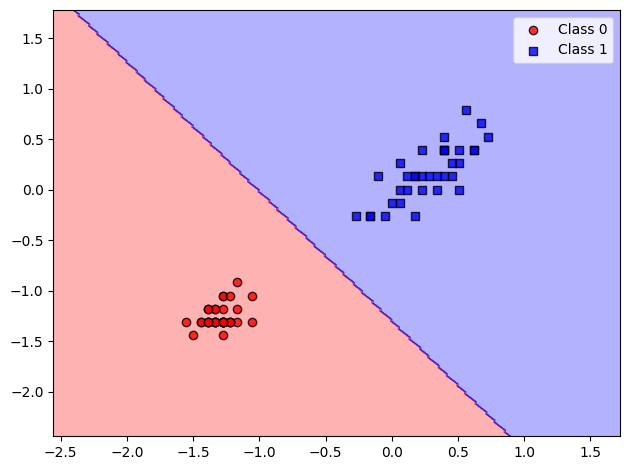

In [6]:
X_train_01_subset = X_train_std[(y_train == 0) | (y_train == 1)]
y_train_01_subset = y_train[(y_train == 0) | (y_train == 1)]

irgd = LogisticRegressionGD(eta=0.3,
                            n_iter=1000)

irgd.fit(X_train_01_subset, y_train_01_subset)

plot_decision_regions(X=X_train_01_subset,
                      y=y_train_01_subset,
                      classifier=irgd)
plt.legend()
plt.tight_layout()
plt.show()

## Model: LogisticRegression. Training & Validation

**Model**: sklearn.linear_model.LogisticRegression | z=wx+b, y_pred=1/1+e**(-z)

**Multi-class classification method**: OvR

**Metrics**: LOG_LOSS

In [7]:
lr = sk.linear_model.LogisticRegression(C=100.0,
                                        solver="lbfgs",
                                        multi_class="ovr")
lr.fit(X_train_std, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(C=100.0, multi_class='ovr')

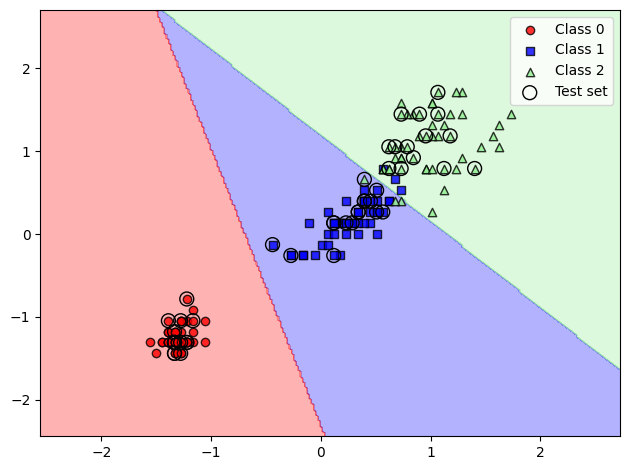

In [8]:
plot_decision_regions(X_combined_std,
                      y_combined,
                      classifier=lr,
                      test_idx=range(105, 150))
plt.legend()
plt.tight_layout()
plt.show()

## Model: DecisionTreeClassifier. Training & Validation

**Model**: sklearn.tree.DecisionTreeClassifier

**Multi-class classification method**: multi-class

In [19]:
tree_model = sk.tree.DecisionTreeClassifier(criterion='gini',
                                            max_depth=4,
                                            random_state=1)
tree_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=1)

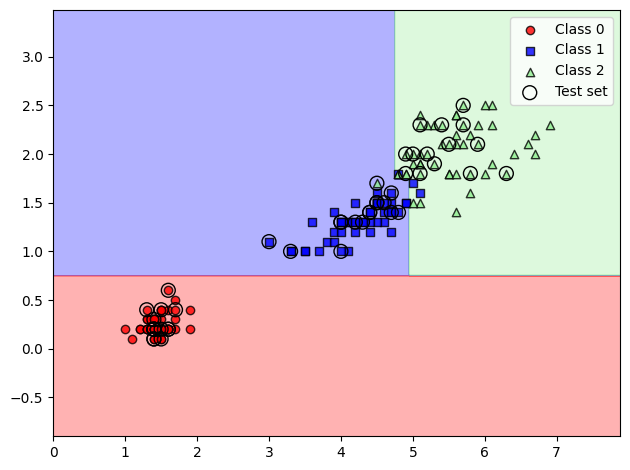

In [20]:
X_combined = np.vstack((X_train, X_test))

plot_decision_regions(X_combined,
                      y_combined,
                      classifier=tree_model,
                      test_idx=range(105, 150))
plt.legend()
plt.tight_layout()
plt.show()

[Text(0.25, 0.9, 'Septal wight <= 0.75\ngini = 0.667\nsamples = 105\nvalue = [35, 35, 35]'),
 Text(0.125, 0.7, 'gini = 0.0\nsamples = 35\nvalue = [35, 0, 0]'),
 Text(0.1875, 0.8, 'True  '),
 Text(0.375, 0.7, 'Septal length <= 4.75\ngini = 0.5\nsamples = 70\nvalue = [0, 35, 35]'),
 Text(0.3125, 0.8, '  False'),
 Text(0.25, 0.5, 'gini = 0.0\nsamples = 30\nvalue = [0, 30, 0]'),
 Text(0.5, 0.5, 'Septal wight <= 1.75\ngini = 0.219\nsamples = 40\nvalue = [0, 5, 35]'),
 Text(0.25, 0.3, 'Septal length <= 4.95\ngini = 0.5\nsamples = 8\nvalue = [0, 4, 4]'),
 Text(0.125, 0.1, 'gini = 0.0\nsamples = 2\nvalue = [0, 2, 0]'),
 Text(0.375, 0.1, 'gini = 0.444\nsamples = 6\nvalue = [0, 2, 4]'),
 Text(0.75, 0.3, 'Septal length <= 4.85\ngini = 0.061\nsamples = 32\nvalue = [0, 1, 31]'),
 Text(0.625, 0.1, 'gini = 0.444\nsamples = 3\nvalue = [0, 1, 2]'),
 Text(0.875, 0.1, 'gini = 0.0\nsamples = 29\nvalue = [0, 0, 29]')]

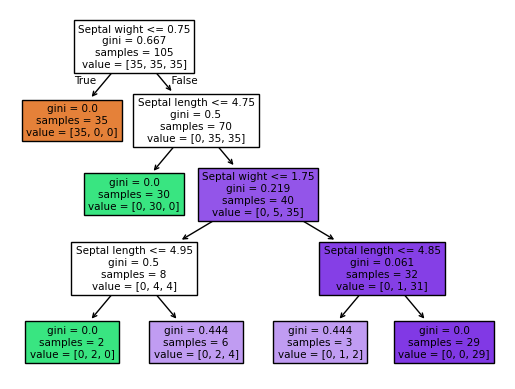

In [21]:
feauture_names = ["Septal length", "Septal wight",
                  "Petal length", "Petal widht"]
sk.tree.plot_tree(tree_model,
                  feature_names=feauture_names,
                  filled=True)

## Model: RandomForestClassifier. Training & Validation

**Model**: sklearn.ensemble.RandomForestClassifier()

**Multi-class classification method**: multi-class

In [25]:
forest = sk.ensemble.RandomForestClassifier(n_estimators=25,
                                         n_jobs=2,
                                         random_state=1)
forest.fit(X_train, y_train)

RandomForestClassifier(n_estimators=25, n_jobs=2, random_state=1)

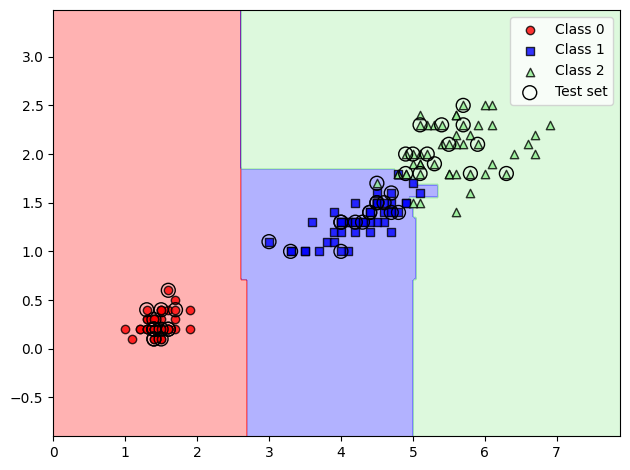

In [27]:
plot_decision_regions(X_combined,
                      y_combined,
                      classifier=forest,
                      test_idx=range(105, 150))
plt.legend()
plt.tight_layout()
plt.show()